In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

################################################# 1 prepare data

X = np.array([
# area, rooms, age, dist
    [70,  3,   15,  5],
    [90,  4,   10,  7],
    [60,  2,   20,  3],
    [120, 5,   5,   10],
    [80,  3,   12,  6],
    [110, 4,   8,   8],
    [100, 4,   7,   5],
    [75,  3,   18,  4],
    [95,  4,   9,   6],
    [130, 5,   3,   12]
])
Y = np.array([1200, 1500, 1100, 1800, 1300, 1650, 1750, 1250, 1550, 1900])

################################################# find weights
model = LinearRegression()
model.fit(X, Y)

print(f'Intercept (β₀) = {model.intercept_}\n')
print(f'Coefficients (β₁, β₂, β₃, β₄) = {model.coef_}\n')

################################################# find MSE 
y_pred = model.predict(X)
MSE = mean_squared_error(Y, y_pred)
print(f'MSE = {MSE:.4f}\n')

################################################# find R²
r2_manual = r2_score(Y, y_pred)
print(f'R² = {r2_manual}\n')

sse = np.sum( (Y - y_pred)**2 )
sst = np.sum( (Y - np.mean(Y))**2 )
r2_manual = 1 - (sse/sst)
print(f'R² = {r2_manual:.4f}\n')

################################################# 
print(f'------------------------------------------------------------- \n')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42)
model.fit(X_train, Y_train)

print(f'Intercept (β₀) = {model.intercept_}\n')
print(f'Coefficients (β₁, β₂, β₃, β₄) = {model.coef_}\n')

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mse_train = mean_squared_error(Y_train, y_pred_train)
mse_test = mean_squared_error(Y_test, y_pred_test)
print(f'mse_train = {mse_train:.4f}\n')
print(f'mse_test = {mse_test:.4f}\n')

r2_train = r2_score(Y_train, y_pred_train)
r2_test = r2_score(Y_test, y_pred_test)
print(f'R² - train = {r2_train:.4f}\n')
print(f'R² - test = {r2_test:.4f}\n')

print(f'X_test = \n{X_test}')
print(f'\nX_train = \n{X_train}')

n = X_train.shape[0]
p = X.shape[1]
top = (1 - r2_train) * (n - 1)
bottom = n - p - 1
r2_adj = 1 - (top / bottom)

print(f'\nr2_adj = {r2_adj}\n')

Intercept (β₀) = 740.6555403096949

Coefficients (β₁, β₂, β₃, β₄) = [ 11.31108062  40.10949007 -15.69124359 -41.37800678]

MSE = 839.1952

R² = 0.9878377506382762

R² = 0.9878

------------------------------------------------------------- 

Intercept (β₀) = 728.6162654342293

Coefficients (β₁, β₂, β₃, β₄) = [ 12.16596537  32.17562254 -16.03435193 -46.5027247 ]

mse_train = 753.9060

mse_test = 1355.1405

R² - train = 0.9912

R² - test = -1.1682

X_test = 
[[95  4  9  6]
 [90  4 10  7]]

X_train = 
[[110   4   8   8]
 [ 70   3  15   5]
 [ 75   3  18   4]
 [ 60   2  20   3]
 [130   5   3  12]
 [ 80   3  12   6]
 [120   5   5  10]
 [100   4   7   5]]

r2_adj = 0.9795210017107552



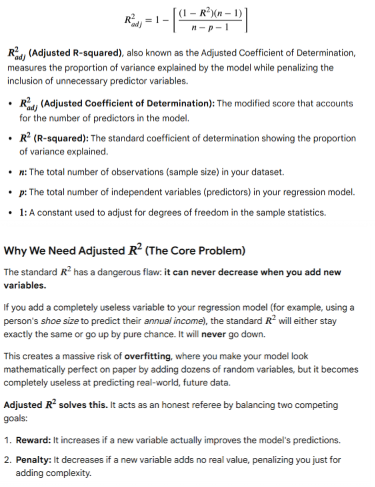

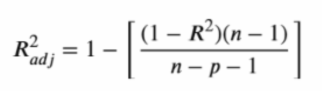

In [3]:
def adjusted_r2(y_train, y_pred, X):
    r2 = r2_score(y_train , y_pred)
    n, p = X.shape  # of train. 8 rows 4 features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
print(adjusted_r2(Y_train, y_pred_train, X_train)) 

0.9795210017107552


In [4]:
# !pip install dmba
from dmba import adjusted_r2_score
adj_r2 = adjusted_r2_score(Y_train, y_pred_train, model)

print('adjusted R2 score', adj_r2)
X.shape

adjusted R2 score 0.9795210017107552


(10, 4)